In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load csv
data = pd.read_csv("student_performance.csv")

#remove accidential space 
data.columns = data.columns.str.strip()

In [3]:
#display dataset

print("Columns in dataset:")
print(data.columns)

print("\nFirst 5 rows:")
print(data.head())

print("\nDataset Info:")
data.info()

Columns in dataset:
Index(['Student_ID', 'Age', 'Gender', 'Study_Hours', 'Attendance',
       'Math_Score', 'Science_Score', 'English_Score', 'Final_Result'],
      dtype='object')

First 5 rows:
  Student_ID  Age  Gender  Study_Hours  Attendance  Math_Score  Science_Score  \
0       S001   18    Male          2.5          85          65           70.0   
1       S002   19  Female          4.0          90          78           82.0   
2       S003   18    Male          1.5          60          45           50.0   
3       S004   20  Female          5.5          95          88           90.0   
4       S005   19    Male          NaN          75          55           60.0   

   English_Score Final_Result  
0           68.0         Pass  
1           80.0         Pass  
2           48.0         Fail  
3           92.0         Pass  
4           58.0         Fail  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Col

In [4]:
#identify missing values
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
Student_ID       0
Age              0
Gender           0
Study_Hours      1
Attendance       0
Math_Score       0
Science_Score    1
English_Score    1
Final_Result     0
dtype: int64


In [5]:
#handle missing values
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())


In [6]:
#Detect and remove outliers (Study_Hours – IQR method)
Q1 = data['Study_Hours'].quantile(0.25)
Q3 = data['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Study_Hours'] >= lower) & (data['Study_Hours'] <= upper)]

print("\nShape after outlier removal:", data.shape)





Shape after outlier removal: (11, 9)


In [7]:
#Normalization (Manual Min–Max, NO ML, numeric only)
for col in numeric_cols:
    data[col] = (data[col] - data[col].min()) / (data[col].max() - data[col].min())





In [8]:
print("\nNumerical Descriptive Statistics:")
print(data.describe())

print("\nFinal_Result Column Values:")
print(data['Final_Result'])

print("\nFinal_Result Distribution:")
print(data['Final_Result'].value_counts())

grouped = data.groupby('Final_Result').mean(numeric_only=True).reset_index()

print("\nMean Values Grouped by Final_Result:")
print(grouped)



Numerical Descriptive Statistics:
             Age  Study_Hours  Attendance  Math_Score  Science_Score  \
count  11.000000    11.000000   11.000000   11.000000      11.000000   
mean    0.386364     0.417355    0.610606    0.497403       0.516595   
std     0.342119     0.318117    0.325941    0.327378       0.343045   
min     0.000000     0.000000    0.000000    0.000000       0.000000   
25%     0.125000     0.178571    0.375000    0.250000       0.253968   
50%     0.250000     0.357143    0.666667    0.500000       0.555556   
75%     0.625000     0.616883    0.875000    0.757143       0.809524   
max     1.000000     1.000000    1.000000    1.000000       1.000000   

       English_Score  
count      11.000000  
mean        0.555569  
std         0.327049  
min         0.000000  
25%         0.313433  
50%         0.588874  
75%         0.805970  
max         1.000000  

Final_Result Column Values:
0     Pass
1     Pass
2     Fail
3     Pass
4     Fail
5     Pass
6     Pass
7  

## Data Visualization

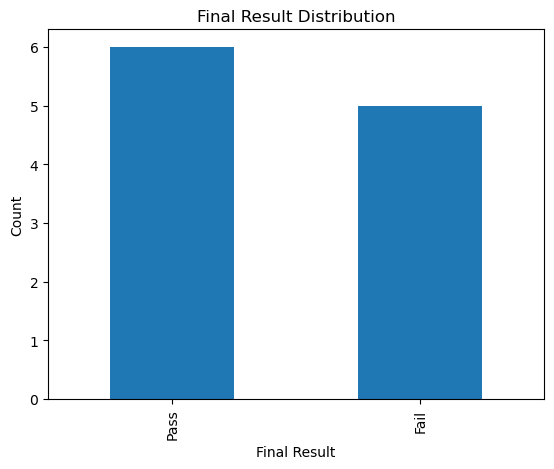

In [9]:
#bar chart
data['Final_Result'].value_counts().plot(kind='bar')
plt.title("Final Result Distribution")
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.show()


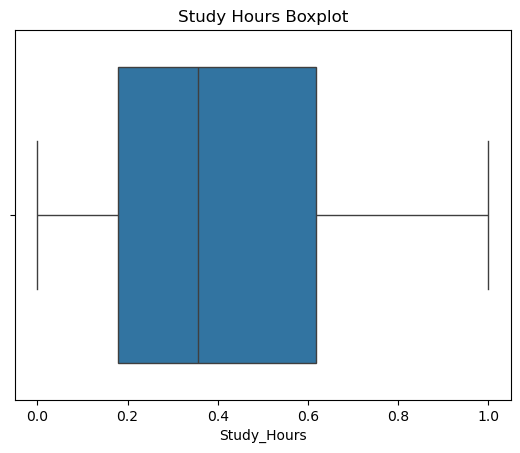

In [13]:
#boxplot
sns.boxplot(x=data['Study_Hours'])
plt.title("Study Hours Boxplot")
plt.show()


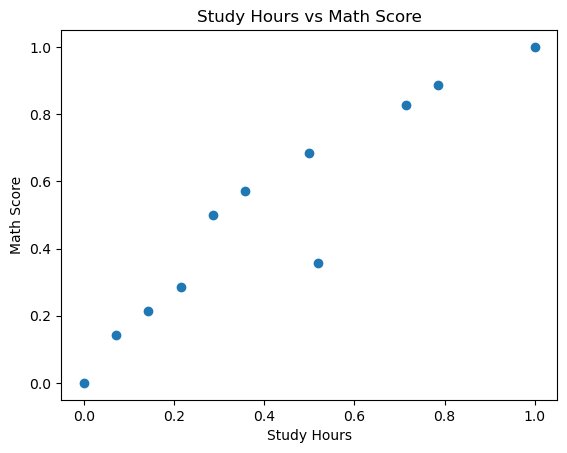

In [14]:
plt.scatter(data['Study_Hours'], data['Math_Score'])
plt.xlabel("Study Hours")
plt.ylabel("Math Score")
plt.title("Study Hours vs Math Score")
plt.show()


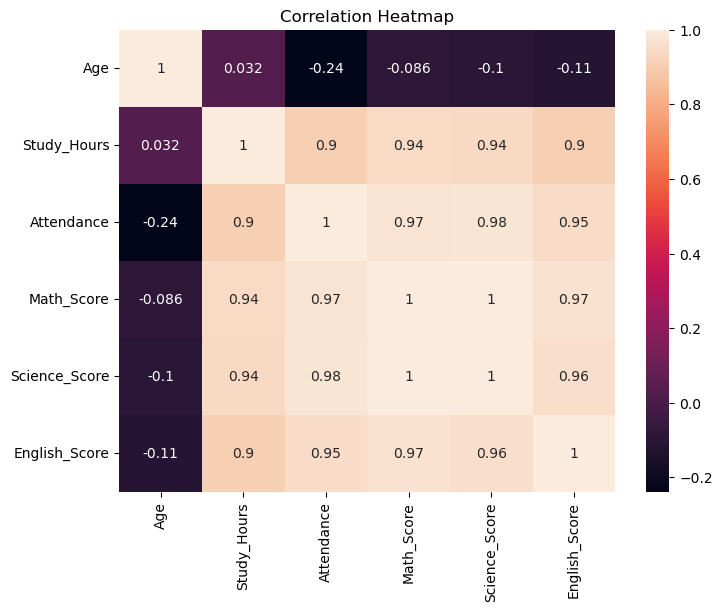

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()
